In [70]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import mean_squared_error, r2_score

In [2]:
df = pd.read_csv("train.csv")

In [3]:
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   str    
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1459 non-null   str    
 3   LotFrontage    1200 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1459 non-null   str    
 8   LandContour    1459 non-null   str    
 9   Utilities      1459 non-null   str    
 10  LotConfig      1459 non-null   str    
 11  LandSlope      1459 non-null   str    
 12  Neighborhood   1459 non-null   str    
 13  Condition1     1459 non-null   str    
 14  Condition2     1459 non-null   str    
 15  BldgType       1459 non-null   str    
 16  HouseStyle     1459 non-null   str    
 17  OverallQual    1459 non-null   int64  
 18  OverallCond    1459

In [5]:
df.describe()

,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1459.000000,1200.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1451.00000,1459.000000,1459.000000,...,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000,1459.000000
mean,56.922550,70.051667,10517.376285,6.100069,5.575051,1971.282385,1984.858122,103.75672,443.910212,45.875942,...,94.058259,46.692255,21.892392,3.411926,15.071282,2.760795,43.518849,6.323509,2007.814256,180947.786840
std,42.304033,24.294805,9984.665289,1.383171,1.113125,30.208122,20.650426,181.10815,456.137321,159.308801,...,125.179476,66.267472,61.094577,29.327247,55.775138,40.191018,496.291826,2.703869,1.327318,79463.242005
min,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,20.000000,59.000000,7549.000000,5.000000,5.000000,1954.000000,1967.000000,0.00000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129950.000000
50%,50.000000,69.500000,9477.000000,6.000000,5.000000,1973.000000,1994.000000,0.00000,384.000000,0.000000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,70.000000,80.000000,11603.000000,7.000000,6.000000,2000.000000,2004.000000,166.00000,712.500000,0.000000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.00000,5644.000000,1474.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
df.shape

(1459, 81)

In [7]:
numirical_column = df.select_dtypes(include='number')

In [8]:
len(df.select_dtypes(include='number').columns)

37

In [9]:
categorical_column = df.select_dtypes(include="object").columns


/var/folders/qp/mnlhrt5x2rx27zstwr3s8_200000gp/T/ipykernel_4029/821130292.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_column = df.select_dtypes(include="object").columns


In [10]:
categorical_column 

Index(['Id', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour',
       'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
       'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC',
       'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='str')

In [11]:
df.columns

Index(['Id', 'MSSubClass', 'MSZoning', 'LotFrontage', 'LotArea', 'Street',
       'Alley', 'LotShape', 'LandContour', 'Utilities', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', 'OverallQual', 'OverallCond', 'YearBuilt', 'YearRemodAdd',
       'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
       'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
       'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType',
       'GarageYrBlt', 'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual',
       'GarageCond', 'PavedDrive

<Axes: >

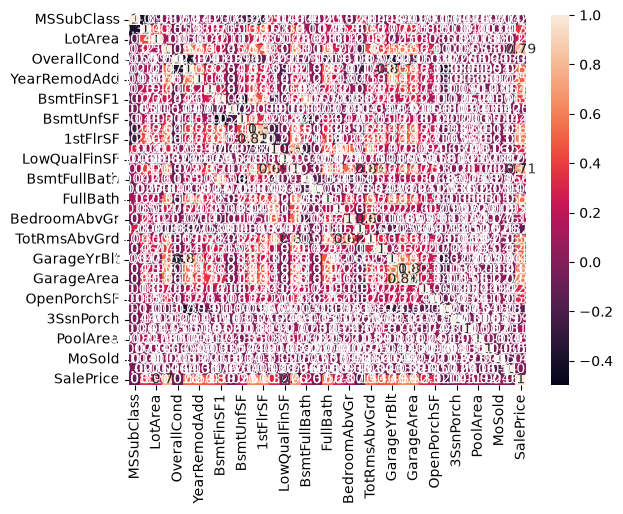

In [12]:
plt.Figure(figsize=(10,7))
sns.heatmap(numirical_column.corr() , annot= True)

In [13]:
corr = numirical_column.corr()['SalePrice'].sort_values(ascending=False)

In [14]:
corr.head(10)


SalePrice       1.000000
OverallQual     0.790951
GrLivArea       0.708572
GarageCars      0.640349
GarageArea      0.623371
TotalBsmtSF     0.613647
1stFlrSF        0.605838
FullBath        0.560568
TotRmsAbvGrd    0.533614
YearBuilt       0.522793
Name: SalePrice, dtype: float64

In [15]:
most_Effect_Columns = corr.head(12).index
print(most_Effect_Columns)

Index(['SalePrice', 'OverallQual', 'GrLivArea', 'GarageCars', 'GarageArea',
       'TotalBsmtSF', '1stFlrSF', 'FullBath', 'TotRmsAbvGrd', 'YearBuilt',
       'YearRemodAdd', 'GarageYrBlt'],
      dtype='str')


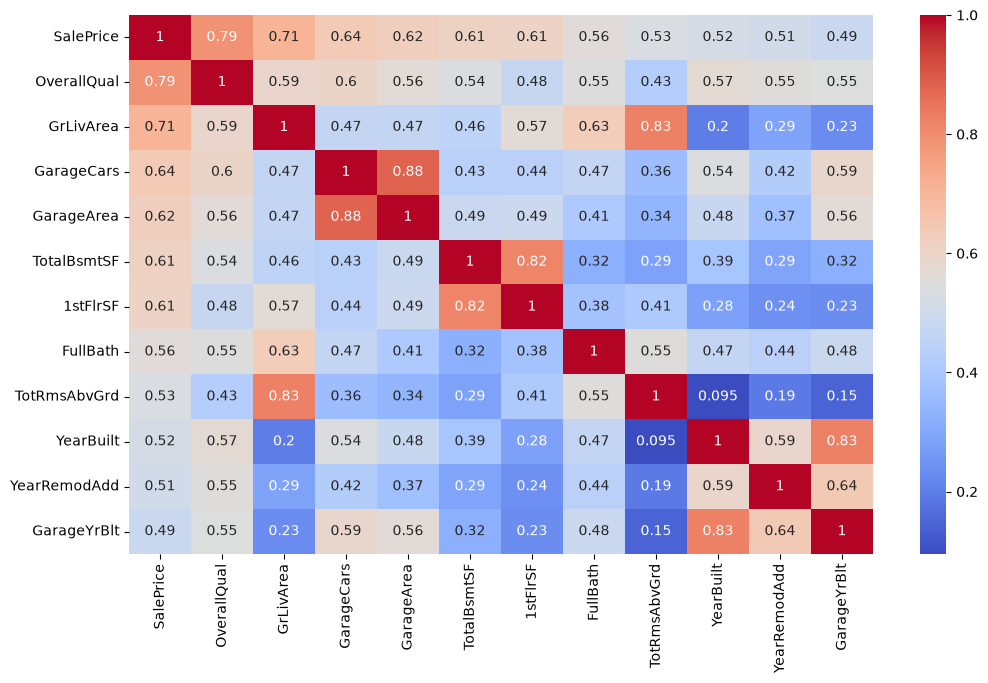

In [16]:
plt.figure(figsize=(12, 7))
sns.heatmap(df[most_Effect_Columns].corr() ,annot=True,cmap='coolwarm' )
plt.show()

### noticed  that  features  have  a  high  correlation  together  (Multicollinearity)  and for feature engineering we will drop any of pair 

In [17]:
cols_To_drop = ['GarageYrBlt' ,'1stFlrSF' , 'GarageCars','TotRmsAbvGrd' ]
df = df.drop(columns=cols_To_drop)

In [18]:
Little_Effect_Columns =  corr.tail(10).index
print(Little_Effect_Columns)

Index(['3SsnPorch', 'BsmtFinSF2', 'BsmtHalfBath', 'MiscVal', 'LowQualFinSF',
       'YrSold', 'OverallCond', 'MSSubClass', 'EnclosedPorch', 'KitchenAbvGr'],
      dtype='str')


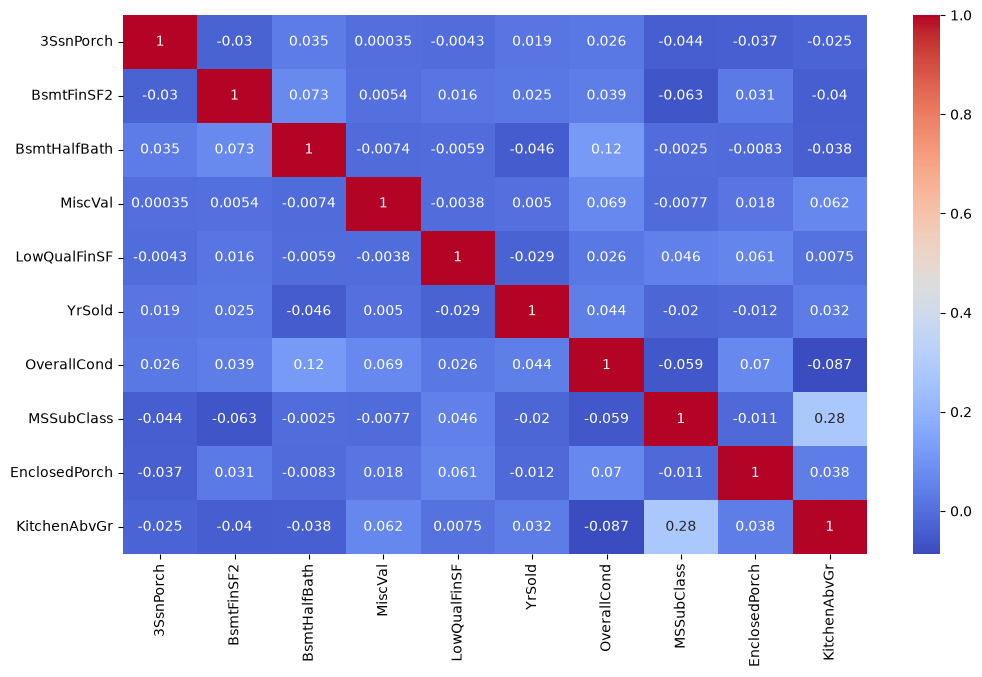

In [19]:
plt.figure(figsize=(12, 7))
sns.heatmap(df[Little_Effect_Columns].corr() ,annot=True,cmap='coolwarm' )
plt.show()

### remove the low correlation as a redundant and noise data (Drop column)

In [20]:
noise_cols = ['3SsnPorch', 'BsmtFinSF2', 'BsmtHalfBath', 'MiscVal', 'LowQualFinSF', 'EnclosedPorch']
df = df.drop(columns=noise_cols, errors='ignore')


### Remove id column also 

## NULLS

In [21]:
for i in numirical_column:
    if df[i].isna().sum()>0:
        print(f"{i} : {df[i].isna().sum()}")

LotFrontage : 259
MasVnrArea : 8


KeyError: 'BsmtFinSF2'

In [22]:
for i in categorical_column:
    if df[i].isna().sum()>0:
        print(f"{i} : {df[i].isna().sum()}")

Alley : 1368
MasVnrType : 871
BsmtQual : 37
BsmtCond : 37
BsmtExposure : 38
BsmtFinType1 : 37
BsmtFinType2 : 38
Electrical : 1
FireplaceQu : 689
GarageType : 81
GarageFinish : 81
GarageQual : 81
GarageCond : 81
PoolQC : 1452
Fence : 1178
MiscFeature : 1405


In [23]:
print(f"nunique : {df['LotFrontage'].nunique()}")
print(f"mode : {df['LotFrontage'].mode()}")
print(f"min : {df['LotFrontage'].min()}")
print(f"max : {df['LotFrontage'].max()}")
print(f"mean : {df['LotFrontage'].mean()}")
print(f"meadian : {df['LotFrontage'].median()}")

nunique : 110
mode : 0    60.0
Name: LotFrontage, dtype: float64
min : 21.0
max : 313.0
mean : 70.05166666666666
meadian : 69.5


In [24]:
df['LotFrontage'].head(25)

0      65.0
1      80.0
2      68.0
3      60.0
4      84.0
5      85.0
6      75.0
7       NaN
8      51.0
9      50.0
10     70.0
11     85.0
12      NaN
13     91.0
14      NaN
15     51.0
16      NaN
17     72.0
18     66.0
19     70.0
20    101.0
21     57.0
22     75.0
23     44.0
24      NaN
Name: LotFrontage, dtype: float64

In [25]:
df['LotFrontage']=df['LotFrontage'].fillna(df['LotFrontage'].mean())

In [26]:
print(f"nunique : {df['MasVnrArea'].nunique()}")
print(f"mode : {df['MasVnrArea'].mode()}")
print(f"min : {df['MasVnrArea'].min()}")
print(f"max : {df['MasVnrArea'].max()}")
print(f"mean : {df['MasVnrArea'].mean()}")
print(f"meadian : {df['MasVnrArea'].median()}")

nunique : 327
mode : 0    0.0
Name: MasVnrArea, dtype: float64
min : 0.0
max : 1600.0
mean : 103.75671950379049
meadian : 0.0


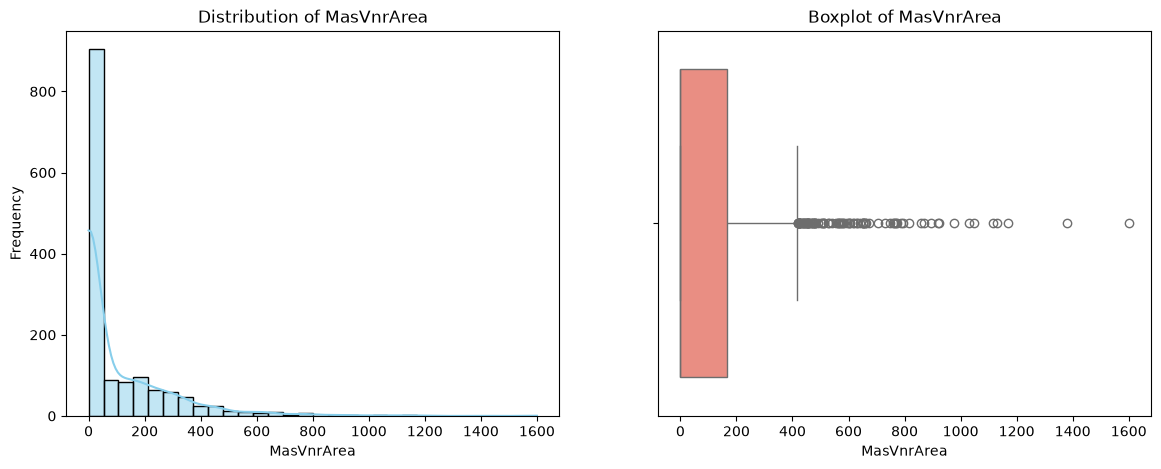

In [27]:

column_name = 'MasVnrArea' 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[column_name], kde=True, bins=30, ax=axes[0], color='skyblue')
axes[0].set_title(f'Distribution of {column_name}')
axes[0].set_xlabel(column_name)
axes[0].set_ylabel('Frequency')

sns.boxplot(x=df[column_name], ax=axes[1], color='salmon')
axes[1].set_title(f'Boxplot of {column_name}')
axes[1].set_xlabel(column_name)

plt.show()


In [28]:
df['MasVnrArea'] = df['MasVnrArea'].fillna(0)

In [29]:
for i in numirical_column:
    if df[i].isna().sum()>0:
        print(f"{i} : {df[i].isna().sum()}")

KeyError: 'BsmtFinSF2'

In [30]:
print(f"nunique : {df['GarageYrBlt'].nunique()}")
print(f"mode : {df['GarageYrBlt'].mode()}")
print(f"min : {df['GarageYrBlt'].min()}")
print(f"max : {df['GarageYrBlt'].max()}")
print(f"mean : {df['GarageYrBlt'].mean()}")
print(f"meadian : {df['GarageYrBlt'].median()}")

KeyError: 'GarageYrBlt'

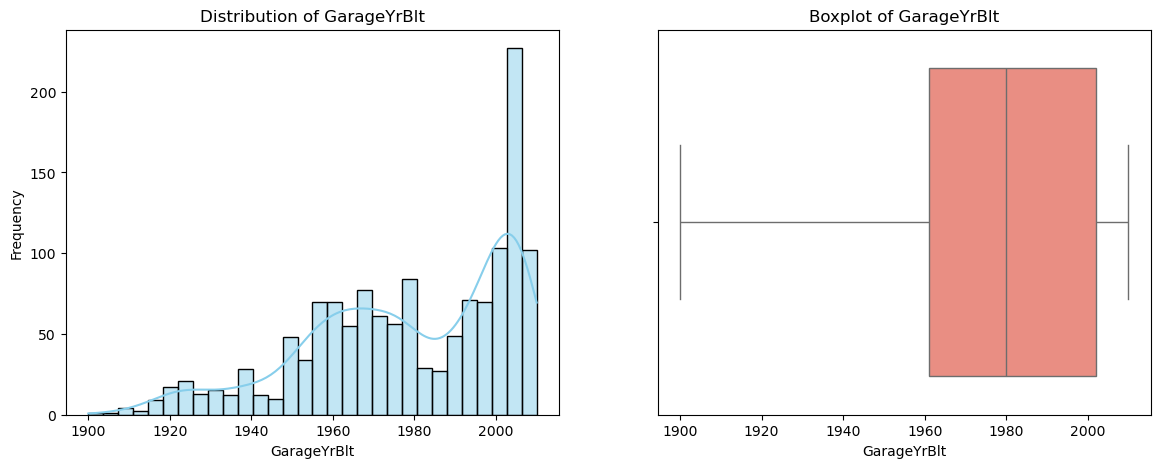

In [ ]:

column_name = 'GarageYrBlt' 

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[column_name], kde=True, bins=30, ax=axes[0], color='skyblue')
axes[0].set_title(f'Distribution of {column_name}')
axes[0].set_xlabel(column_name)
axes[0].set_ylabel('Frequency')

sns.boxplot(x=df[column_name], ax=axes[1], color='salmon')
axes[1].set_title(f'Boxplot of {column_name}')
axes[1].set_xlabel(column_name)

plt.show()


In [ ]:
df['GarageYrBlt'] = df['GarageYrBlt'] .fillna(df['GarageYrBlt'].median())

In [ ]:
for i in categorical_column:
    if df[i].isna().sum()>0:
        print(f"{i} : {df[i].isna().sum()}")

KeyError: 'Id'

In [31]:
df.Alley.nunique()

2

هعملها one hot encoding بس لسه شويه لما اعمل train test split

In [32]:
df["Alley"] = df["Alley"].fillna("None")

In [33]:
print(df.MasVnrType.mode())
print(df.MasVnrType.nunique())

0    BrkFace
Name: MasVnrType, dtype: str
3


In [34]:
df["MasVnrType"] = df["MasVnrType"].fillna("None")

هعملها one hot encoding بس لسه شويه لما اعمل train test split

In [35]:
df.BsmtQual.nunique()
df.BsmtCond.nunique()

4

هملا بال none لانها بتدل ان البيت لا يحتوي علي بادرون اصلا 

In [36]:
df["BsmtQual"] = df["BsmtQual"].fillna("None")
df["BsmtCond"] = df["BsmtCond"].fillna("None")

هعملها one hot encoding بس لسه شويه لما اعمل train test split

In [37]:
for i in categorical_column:
    if df[i].isna().sum() > 0 and df[i].isna().sum() < 100:
        print(f"{i} : {df[i].isna().sum()}")
        print(f"mode : {df[i].mode()}")
        print(f"Nunique : {df[i].nunique()}")
        print(f"uniques : {df[i].unique()}")
        print("*" * 20)

BsmtExposure : 38
mode : 0    No
Name: BsmtExposure, dtype: str
Nunique : 4
uniques : <StringArray>
['No', 'Gd', 'Mn', 'Av', nan]
Length: 5, dtype: str
********************
BsmtFinType1 : 37
mode : 0    Unf
Name: BsmtFinType1, dtype: str
Nunique : 6
uniques : <StringArray>
['GLQ', 'ALQ', 'Unf', 'Rec', 'BLQ', nan, 'LwQ']
Length: 7, dtype: str
********************
BsmtFinType2 : 38
mode : 0    Unf
Name: BsmtFinType2, dtype: str
Nunique : 6
uniques : <StringArray>
['Unf', 'BLQ', nan, 'ALQ', 'Rec', 'LwQ', 'GLQ']
Length: 7, dtype: str
********************
Electrical : 1
mode : 0    SBrkr
Name: Electrical, dtype: str
Nunique : 5
uniques : <StringArray>
['SBrkr', 'FuseF', 'FuseA', 'FuseP', 'Mix', nan]
Length: 6, dtype: str
********************
GarageType : 81
mode : 0    Attchd
Name: GarageType, dtype: str
Nunique : 6
uniques : <StringArray>
['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types']
Length: 7, dtype: str
********************
GarageFinish : 81
mode : 0    Unf
Name: G

In [38]:
df['BsmtExposure'] = df['BsmtExposure'].fillna(df['BsmtExposure'] .mode()[0]) 
df['BsmtFinType1'] = df['BsmtFinType1'].fillna(df['BsmtFinType1'] .mode()[0]) 
df['BsmtFinType2'] = df['BsmtFinType2'].fillna(df['BsmtFinType2'] .mode()[0]) 
df['Electrical'] = df['Electrical'].fillna(df['Electrical'] .mode()[0]) 

In [39]:
for i in categorical_column:
    if df[i].isna().sum()>0:
        print(f"{i} : {df[i].isna().sum()}")

FireplaceQu : 689
GarageType : 81
GarageFinish : 81
GarageQual : 81
GarageCond : 81
PoolQC : 1452
Fence : 1178
MiscFeature : 1405


In [40]:
for i in categorical_column:
    if df[i].isna().sum() > 0 :
        print(f"{i} : {df[i].isna().sum()}")
        print(f"mode : {df[i].mode()}")
        print(f"Nunique : {df[i].nunique()}")
        print(f"uniques : {df[i].unique()}")
        print("*" * 20)

FireplaceQu : 689
mode : 0    Gd
Name: FireplaceQu, dtype: str
Nunique : 5
uniques : <StringArray>
[nan, 'TA', 'Gd', 'Fa', 'Ex', 'Po']
Length: 6, dtype: str
********************
GarageType : 81
mode : 0    Attchd
Name: GarageType, dtype: str
Nunique : 6
uniques : <StringArray>
['Attchd', 'Detchd', 'BuiltIn', 'CarPort', nan, 'Basment', '2Types']
Length: 7, dtype: str
********************
GarageFinish : 81
mode : 0    Unf
Name: GarageFinish, dtype: str
Nunique : 3
uniques : <StringArray>
['RFn', 'Unf', 'Fin', nan]
Length: 4, dtype: str
********************
GarageQual : 81
mode : 0    TA
Name: GarageQual, dtype: str
Nunique : 5
uniques : <StringArray>
['TA', 'Fa', 'Gd', nan, 'Ex', 'Po']
Length: 6, dtype: str
********************
GarageCond : 81
mode : 0    TA
Name: GarageCond, dtype: str
Nunique : 5
uniques : <StringArray>
['TA', 'Fa', nan, 'Gd', 'Po', 'Ex']
Length: 6, dtype: str
********************
PoolQC : 1452
mode : 0    Gd
Name: PoolQC, dtype: str
Nunique : 3
uniques : <StringArray>

In [41]:
for col in ["GarageType","GarageFinish","GarageQual","GarageCond"]:
    df[col] = df[col].fillna("None") 


In [42]:

other_None_cols = [
    'FireplaceQu', 'GarageType', 'GarageFinish', 
    'GarageQual', 'GarageCond', 'PoolQC', 'Fence', 'MiscFeature'
]

In [43]:
for col in other_None_cols:
    df[col] = df[col].fillna("None") 


In [44]:
print(df.isna().sum().sum())

0


## Duplicate

In [ ]:
df.duplicated().sum()

np.int64(0)

### Train test split before scaling and transformation for preventing data leakage

In [45]:
X = df.drop(columns=['SalePrice' , 'Id'])
Y = df['SalePrice']

In [46]:
X_train , X_test , Y_train , Y_test = train_test_split(X,Y , test_size=0.2 , random_state=42)

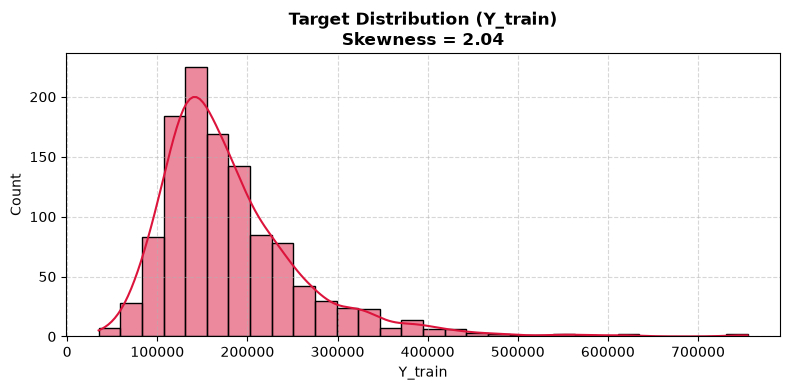

In [ ]:

import math

# Target 
plt.figure(figsize=(8, 4))
sns.histplot(Y_train, kde=True, color='crimson', bins=30)
plt.title(f"Target Distribution (Y_train)\nSkewness = {Y_train.skew():.2f}", fontsize=12, fontweight='bold')
plt.xlabel("Y_train", fontsize=10)
plt.ylabel("Count", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()




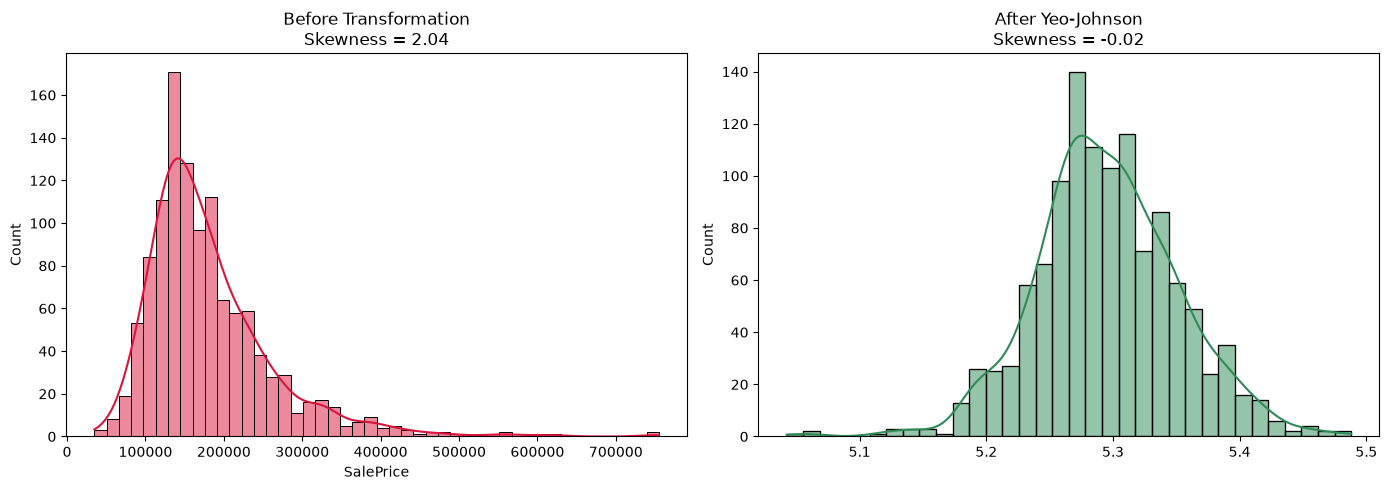

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer

# 1. معالجة Y_train باستخدام Yeo-Johnson
pt = PowerTransformer(method='yeo-johnson', standardize=False)
Y_train_transformed = pt.fit_transform(Y_train.values.reshape(-1, 1)).flatten()

# 2. رسم المقارنة بين القديم والجديد
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: قبل المعالجة
sns.histplot(Y_train, kde=True, color='crimson', ax=axes[0])
axes[0].set_title(f'Before Transformation\nSkewness = {Y_train.skew():.2f}')

# Plot 2: بعد المعالجة
sns.histplot(Y_train_transformed, kde=True, color='seagreen', ax=axes[1])
axes[1].set_title(f'After Yeo-Johnson\nSkewness = {pd.Series(Y_train_transformed).skew():.2f}')

plt.tight_layout()
plt.show()


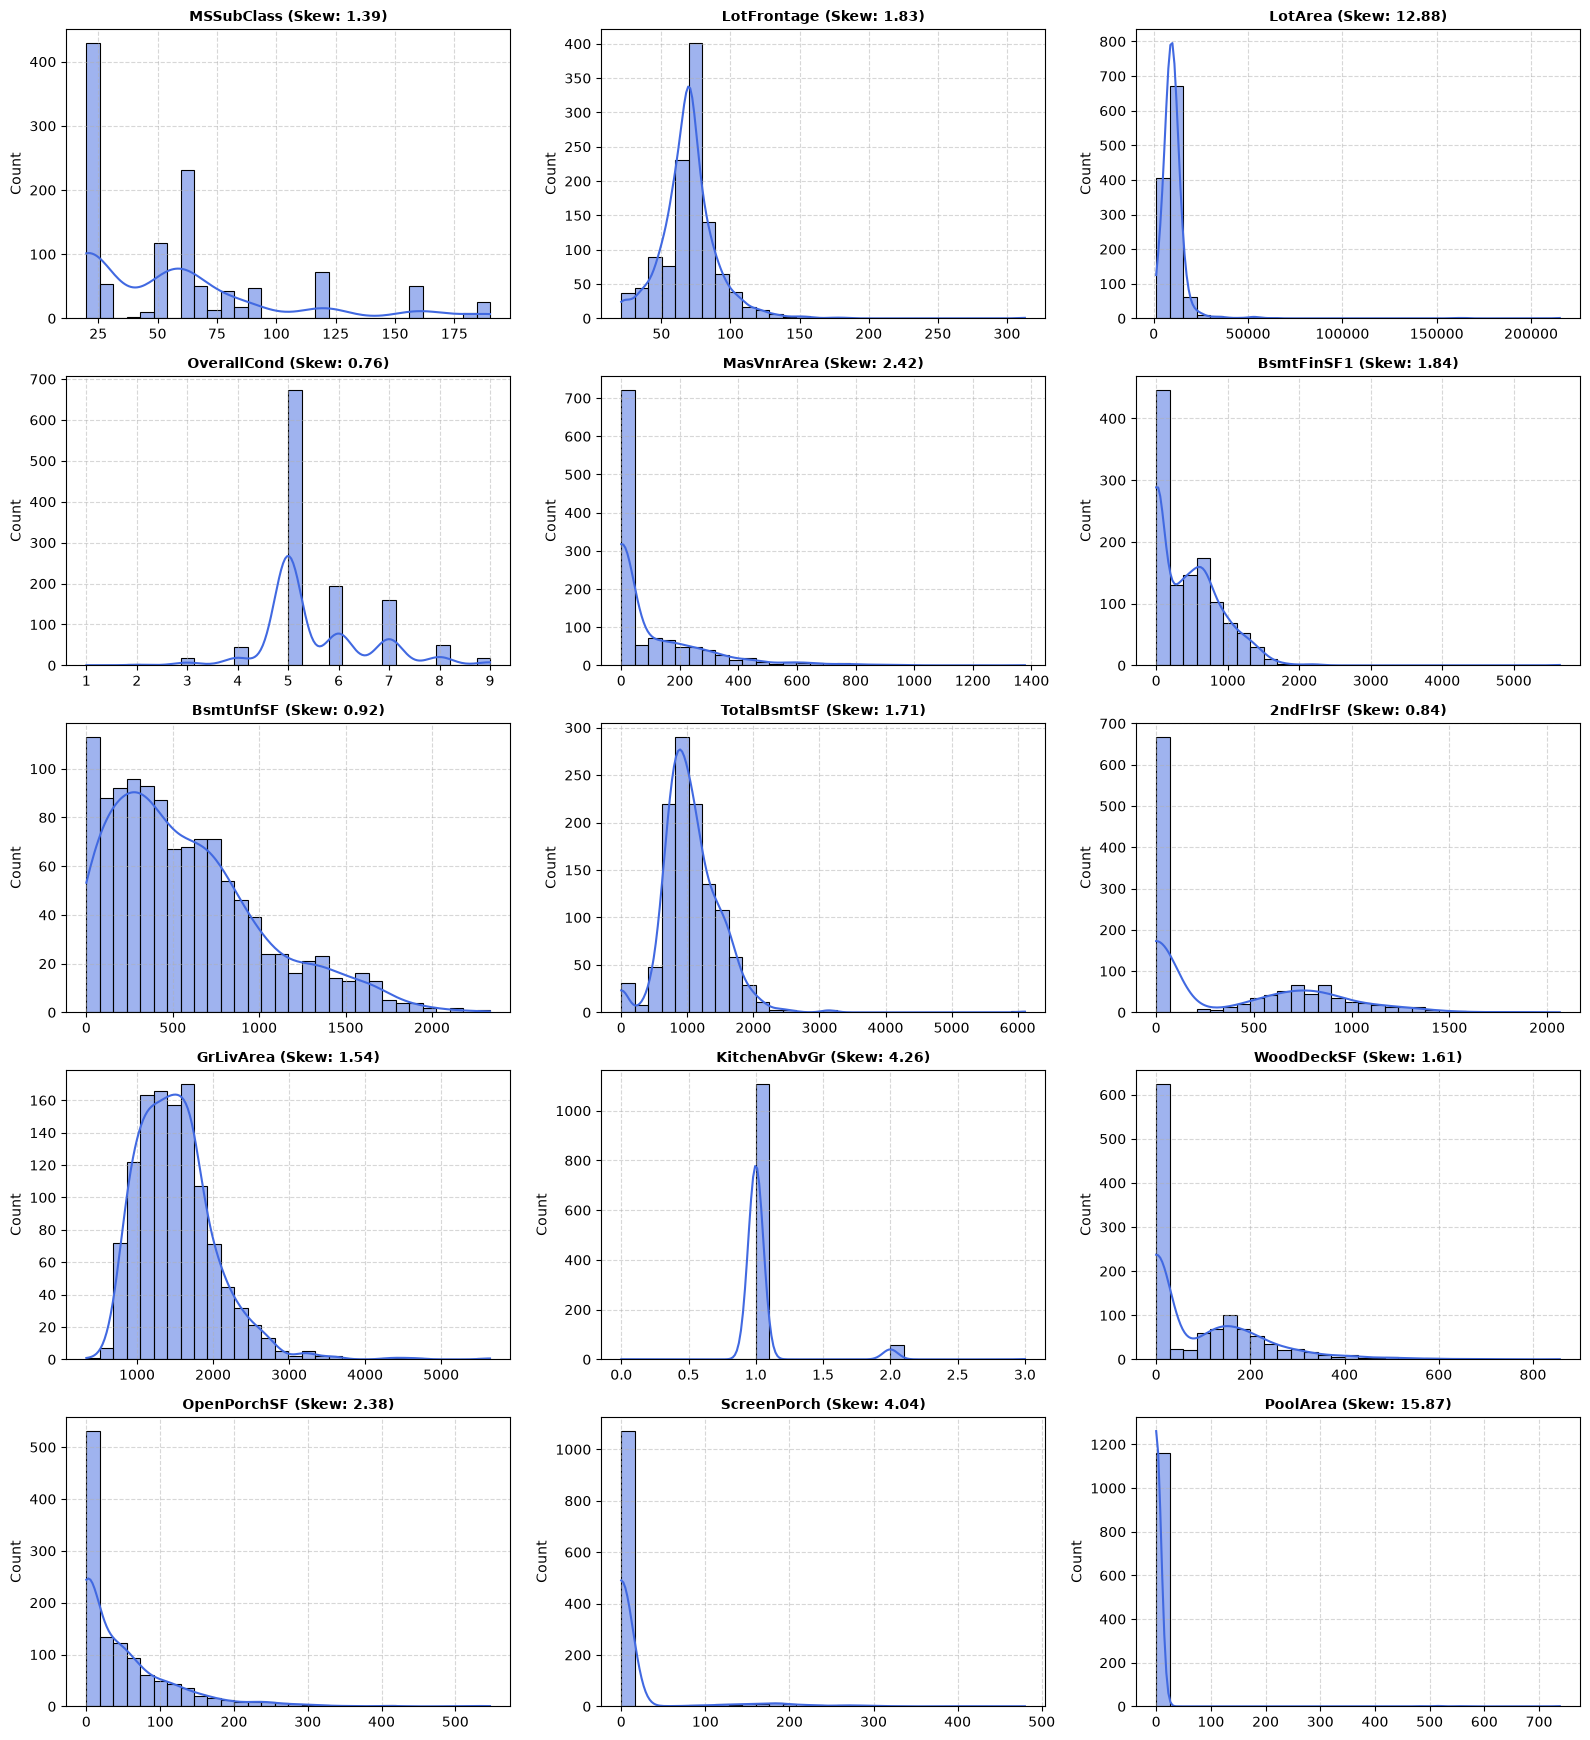

In [53]:

# Subplot
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
skewed_cols = [
    col for col in numeric_cols 
    if abs(X_train[col].skew()) > 0.75 and X_train[col].nunique() > 2
]

n_features = len(skewed_cols)

if n_features > 0:
    cols_per_row = 3
    rows = math.ceil(n_features / cols_per_row)
    
    fig, axes = plt.subplots(rows, cols_per_row, figsize=(16, 3.5 * rows))
    axes = axes.flatten() if n_features > 1 else [axes]

    for i, col in enumerate(skewed_cols):
        skew_val = X_train[col].skew()
        sns.histplot(X_train[col], kde=True, ax=axes[i], color='royalblue', bins=30)
        axes[i].set_title(f"{col} (Skew: {skew_val:.2f})", fontsize=10, fontweight='bold')
        axes[i].grid(True, linestyle='--', alpha=0.5)
        axes[i].set_xlabel('')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("No")

## Encoding

In [26]:
# for col in categorical_column :
#     print(col, end= "\n")
#     for i in df[col].unique():
#         print(i," | ", end= "")


In [27]:
categorical_column

Index(['Id', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour',
       'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
       'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
       'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',
       'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC',
       'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'],
      dtype='str')

In [28]:
print(df["Neighborhood"] .unique())
print(df["Exterior1st"] .unique())
print(df["Exterior2nd"] .unique())


<StringArray>
['CollgCr', 'Veenker', 'Crawfor', 'NoRidge', 'Mitchel', 'Somerst',  'NWAmes',
 'OldTown', 'BrkSide',  'Sawyer', 'NridgHt',   'NAmes', 'SawyerW',  'IDOTRR',
 'MeadowV', 'Edwards',  'Timber', 'Gilbert', 'StoneBr', 'ClearCr', 'NPkVill',
 'Blmngtn',  'BrDale',   'SWISU', 'Blueste']
Length: 25, dtype: str
<StringArray>
['VinylSd', 'MetalSd', 'Wd Sdng', 'HdBoard', 'BrkFace', 'WdShing', 'CemntBd',
 'Plywood', 'AsbShng',  'Stucco', 'BrkComm', 'AsphShn',   'Stone', 'ImStucc',
  'CBlock']
Length: 15, dtype: str
<StringArray>
['VinylSd', 'MetalSd', 'Wd Shng', 'HdBoard', 'Plywood', 'Wd Sdng', 'CmentBd',
 'BrkFace',  'Stucco', 'AsbShng', 'Brk Cmn', 'ImStucc', 'AsphShn',   'Stone',
   'Other',  'CBlock']
Length: 16, dtype: str


### Target encoder

In [ ]:
from category_encoders import TargetEncoder
target_cols = ['Neighborhood', 'Exterior1st', 'Exterior2nd']
te = TargetEncoder(cols=target_cols, smoothing=10, min_samples_leaf=5)
X_train[target_cols] = te.fit_transform(X_train[target_cols], Y_train)
X_test[target_cols] = te.transform(X_test[target_cols])


In [57]:
print(X_train[target_cols].head())


       Neighborhood    Exterior1st    Exterior2nd
254   145938.973512  148792.487060  149226.230052
1065  207719.009016  148903.375046  147201.743232
864   224871.989199  214503.198565  215056.486553
798   320351.540442  214503.198565  215056.486553
380   148753.595663  201895.838461  147201.743232


In [58]:
# 1. خريطة التقييمات القياسية
qual_map = {'None': 0, 'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5}
std_qual_cols = [
    'ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC',
    'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond', 'PoolQC'
]

# 2. تطبيق التحويل على البيانات
for df in [X_train, X_test]:
    # تحويل التقييمات القياسية
    for col in std_qual_cols:
        if col in df.columns:
            df[col] = df[col].map(qual_map).fillna(0)
            
    if 'BsmtExposure' in df.columns:
        df['BsmtExposure'] = df['BsmtExposure'].map({'None': 0, 'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}).fillna(0)
    
    bsmt_fin = {'None': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}
    if 'BsmtFinType1' in df.columns:
        df['BsmtFinType1'] = df['BsmtFinType1'].map(bsmt_fin).fillna(0)
    if 'BsmtFinType2' in df.columns:
        df['BsmtFinType2'] = df['BsmtFinType2'].map(bsmt_fin).fillna(0)
        
    if 'GarageFinish' in df.columns:
        df['GarageFinish'] = df['GarageFinish'].map({'None': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}).fillna(0)
    if 'LotShape' in df.columns:
        df['LotShape'] = df['LotShape'].map({'IR3': 1, 'IR2': 2, 'IR1': 3, 'Reg': 4}).fillna(0)
    if 'LandSlope' in df.columns:
        df['LandSlope'] = df['LandSlope'].map({'Sev': 1, 'Mod': 2, 'Gtl': 3}).fillna(0)
    if 'CentralAir' in df.columns:
        df['CentralAir'] = df['CentralAir'].map({'N': 0, 'Y': 1}).fillna(0)
    if 'PavedDrive' in df.columns:
        df['PavedDrive'] = df['PavedDrive'].map({'N': 0, 'P': 1, 'Y': 2}).fillna(0)
    if 'Functional' in df.columns:
        df['Functional'] = df['Functional'].map({'Sal': 0, 'Sev': 1, 'Maj2': 2, 'Maj1': 3, 'Mod': 4, 'Min2': 5, 'Min1': 6, 'Typ': 7}).fillna(7)


In [59]:
import numpy as np
import pandas as pd

binary_cols = [
    'MSZoning', 'Street', 'Alley', 'LandContour', 'LotConfig', 
    'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 
    'RoofMatl', 'MasVnrType', 'Foundation', 'Heating', 'Electrical', 
    'GarageType', 'Fence', 'MiscFeature', 'SaleType', 'SaleCondition'
]

# فلترة الأعمدة للتأكد من وجودها
binary_cols = [col for col in binary_cols if col in X_train.columns]

for col in binary_cols:
    # 1. ربط الفئات بأرقام تسلسلية بناءً على Train فقط
    categories = X_train[col].dropna().unique()
    mapping = {cat: i + 1 for i, cat in enumerate(categories)}
    
    # تحويل القيم لـ numpy array لتفادي TypeError
    train_codes = X_train[col].map(mapping).fillna(0).astype(int).to_numpy()
    test_codes = X_test[col].map(mapping).fillna(0).astype(int).to_numpy()
    
    # 2. تحويل الأرقام إلى خانات باينري (0 و 1)
    max_val = len(categories) + 1
    n_bits = max_val.bit_length()
    
    for bit in range(n_bits):
        X_train[f'{col}_bin_{bit}'] = (train_codes >> bit) & 1
        X_test[f'{col}_bin_{bit}'] = (test_codes >> bit) & 1
        
    # حذف العمود النصي القديم
    X_train.drop(columns=[col], inplace=True)
    X_test.drop(columns=[col], inplace=True)


/var/folders/qp/mnlhrt5x2rx27zstwr3s8_200000gp/T/ipykernel_4029/62431178.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_train[f'{col}_bin_{bit}'] = (train_codes >> bit) & 1
/var/folders/qp/mnlhrt5x2rx27zstwr3s8_200000gp/T/ipykernel_4029/62431178.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_test[f'{col}_bin_{bit}'] = (test_codes >> bit) & 1
/var/folders/qp/mnlhrt5x2rx27zstwr3s8_200000gp/T/ipykernel_4029/62431178.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `fr

In [62]:
df

,MSSubClass,LotFrontage,LotArea,LotShape,Utilities,LandSlope,Neighborhood,OverallQual,OverallCond,YearBuilt,...,MiscFeature_bin_0,MiscFeature_bin_1,MiscFeature_bin_2,SaleType_bin_0,SaleType_bin_1,SaleType_bin_2,SaleType_bin_3,SaleCondition_bin_0,SaleCondition_bin_1,SaleCondition_bin_2
1321,20,70.051667,6627,3,AllPub,3,126872.772659,3,6,1949,...,1,0,0,1,0,0,0,1,0,0
836,30,90.000000,8100,4,AllPub,3,130767.704302,5,6,1948,...,1,0,0,0,0,1,0,1,0,0
413,30,56.000000,8960,4,AllPub,3,130767.704302,5,6,1927,...,1,0,0,1,0,0,0,1,0,0
522,50,50.000000,5000,4,AllPub,3,126872.772659,6,7,1947,...,1,0,0,1,0,0,0,1,0,0
1035,20,70.051667,11500,3,AllPub,3,128895.265474,4,3,1957,...,1,0,0,1,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
479,30,50.000000,5925,4,AllPub,3,130767.704302,4,7,1937,...,1,0,0,1,0,0,0,0,0,1
1360,70,51.000000,9842,4,AllPub,3,148753.595663,5,6,1921,...,1,0,0,1,0,0,0,1,0,0
1414,50,64.000000,13053,4,AllPub,3,126872.772659,6,7,1923,...,1,0,0,1,0,0,0,1,0,0
650,60,65.000000,8125,4,AllPub,3,224871.989199,7,6,2007,...,1,0,0,1,0,0,0,1,0,0


In [60]:
df.isna().sum()

MSSubClass             0
LotFrontage            0
LotArea                0
LotShape               0
Utilities              0
                      ..
SaleType_bin_2         0
SaleType_bin_3         0
SaleCondition_bin_0    0
SaleCondition_bin_1    0
SaleCondition_bin_2    0
Length: 114, dtype: int64

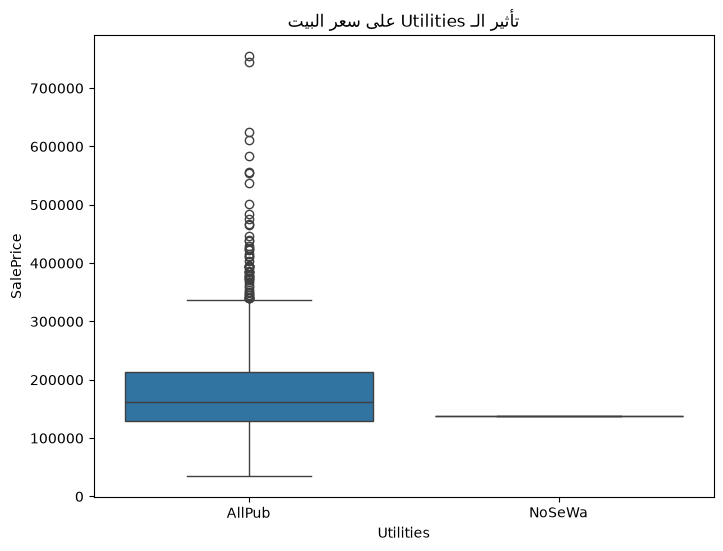

In [64]:
import seaborn as sns
import matplotlib.pyplot as plt

# رسم بياني بيوريك توزيع الأسعار لكل فئة في الـ Utilities
plt.figure(figsize=(8, 6))
sns.boxplot(x=X_train['Utilities'], y=Y_train)
plt.title('تأثير الـ Utilities على سعر البيت')
plt.show()


In [65]:
X_train.drop(columns=['Utilities'], errors='ignore', inplace=True)
X_test.drop(columns=['Utilities'], errors='ignore', inplace=True)


## Scaling

In [66]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("X_train_scaled:", X_train_scaled.shape)

X_train_scaled: (1167, 113)


### Model Application

In [68]:

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, Y_train)



,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"effective_metric_ effective_metric_: str or callableThe distance metric to use. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'
"effective_metric_params_ effective_metric_params_: dictAdditional keyword arguments for the metric function. For most metricswill be same with `metric_params` parameter, but may also contain the`p` parameter value if the `effective_metric_` attribute is set to'minkowski'.",dict,{}


In [69]:
y_train_pred = knn.predict(X_train_scaled)
y_test_pred = knn.predict(X_test_scaled)



In [71]:

train_rmse = np.sqrt(mean_squared_error(Y_train, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(Y_test, y_test_pred))
r2 = r2_score(Y_test, y_test_pred)

print(f"Train RMSE: {train_rmse:,.4f}")
print(f"Test RMSE:  {test_rmse:,.4f}")
print(f"Test R2 Score: {r2:.4f}")


Train RMSE: 33,497.6826
Test RMSE:  34,875.5538
Test R2 Score: 0.7687
